用低分辨率的完成了一次之后下面用较高分辨率进行一次反演

import packges

In [1]:
%matplotlib inline
from __future__ import division, unicode_literals
import numpy as np
import multiprocessing
from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn  # Makes the default style of the plots nicer
import cPickle as pickle
import datetime
from fatiando.inversion import Smoothness2D
from fatiando.vis import mpl
from fatiando.gravmag import tesseroid
from fatiando import utils, gridder
import fatiando
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mohoinv import (MohoGravityInvSpherical, TesseroidRelief, make_mesh,
                     split_data, score_test_set, score_seismic_constraints, 
                     score_all, fit_all, predict_seismic)
import os
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import sys
sys.setrecursionlimit(10000)
print("Using Fatiando a Terra version: {}".format(fatiando.__version__))
ncpu = multiprocessing.cpu_count()
ncpu

d:\conda_envs\moho\lib\site-packages\fatiando\vis\mpl.py:76: UserWarning: This module will be removed in v0.6. We recommend the use of matplotlib.pyplot module directly. Some of the fatiando specific functions will remain.
  "specific functions will remain.")


Using Fatiando a Terra version: 0.5


20

read data

In [2]:
height=11e3

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

data_file = os.path.join(
    PROJECT_ROOT,
    "data",
    "boueguer_frenquency_11km_withoutmoremare_topo_1deg.csv"
)

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

grav_grid = df.pivot(index='lat', columns='lon', values='deltaN').loc[lat_raw, lon_raw].values
topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw) 

In [4]:
test=False
if test:
    lon_min = -40
    lon_max = 5
    lat_min = 10
    lat_max = 55
    pkl_name=os.path.join(
            PROJECT_ROOT,
            "result",
            "run_1p_test.plk"
        )
else:
    lon_min = -180
    lon_max = 180
    lat_min = -90
    lat_max = 90
    pkl_name=os.path.join(
            PROJECT_ROOT,
            "result",
            "run_1p.plk"
        )

In [5]:
lon_indices = np.where((lon_raw >= lon_min) & (lon_raw <= lon_max))[0]
lat_indices = np.where((lat_raw >= lat_min) & (lat_raw <= lat_max))[0]

LON_sub = LON[np.ix_(lat_indices, lon_indices)]
LAT_sub = LAT[np.ix_(lat_indices, lon_indices)]
grav_grid_sub = grav_grid[np.ix_(lat_indices, lon_indices)]
topo_grid_sub = topo_grid[np.ix_(lat_indices, lon_indices)]

LAT_flat = LAT_sub.flatten()
LON_flat = LON_sub.flatten()
grav_flat = grav_grid_sub.flatten()

设置反演器

In [6]:
density_contrast=562
reference=-40e3
mu=1e-10

In [7]:
area=(LAT_flat.min(), LAT_flat.max(), LON_flat.min(), LON_flat.max())
mesh=make_mesh(area,grav_grid_sub.shape)

In [8]:
misfit = MohoGravityInvSpherical(LAT_flat, LON_flat, height*np.ones_like(LON_flat), grav_flat, mesh, njobs=ncpu)
misfit.set_density(density_contrast)
misfit.set_reference(reference)
initial = -40e3*np.ones(mesh.size)  
config = dict(method='newton', initial=initial, tol=0.2, maxit=10)
regul = Smoothness2D(mesh.shape)
solver = (misfit + mu*regul).config(**config) 

反演

In [ ]:
%time solver.fit()

[1748400. 1748400. 1748400. ... 1748400. 1748400. 1748400.]


d:\conda_envs\moho\lib\site-packages\fatiando\gravmag\tesseroid.py:166: RuntimeWarning: Encountered tesseroid with dimensions smaller than the numerical threshold (1e-6 degrees or 1e-3 m). Ignoring this tesseroid.
  warnings.warn(msg, RuntimeWarning)


[1748400. 1748400. 1748400. ... 1748400. 1748400. 1748400.]


查看结果

<Figure size 432x288 with 0 Axes>

Text(0.5,1,u"Convergence of Newton's method")

Text(0,0.5,u'RMS (mGal)')

Text(0.5,0,u'Iteration')

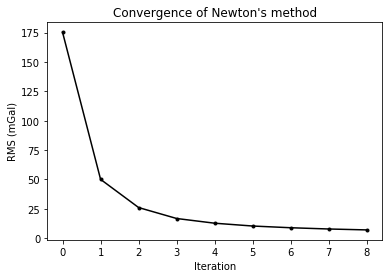

In [ ]:
rms = np.sqrt(solver.stats_['objective'])/np.sqrt(solver[0].ndata)
plt.figure()
ax = plt.subplot(111)
ax.set_title('Convergence of {}'.format(solver.stats_['method']))
ax.plot(rms, '.k-')
ax.set_ylabel('RMS (mGal)')
ax.set_xlabel('Iteration')

In [ ]:
predicted = solver[0].predicted()
residuals = solver[0].residuals()

<Figure size 792x576 with 0 Axes>

d:\conda_envs\moho\lib\site-packages\matplotlib\contour.py:1006: UserWarning: The following kwargs were not used by contour: 'picker'
  s)


Text(0.5,1,u'Observed data')

Text(0.5,1,u'predicted data')

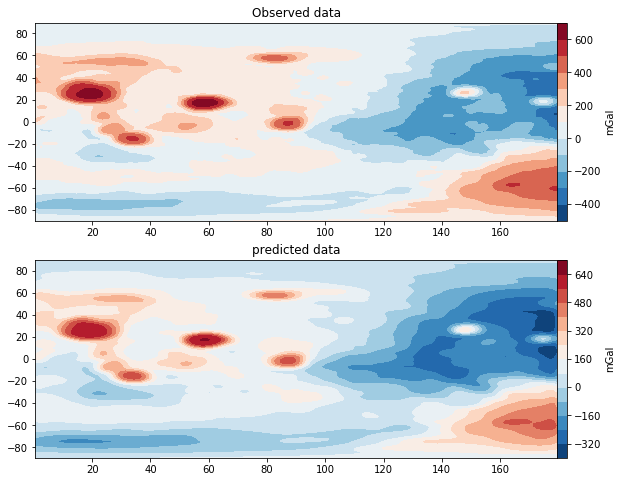

In [ ]:
plt.figure(figsize=(11, 8))
plt.subplot(2,1,1)
levels = mpl.contourf(LON_sub, LAT_sub, grav_grid_sub, grav_grid_sub.shape, 12, cmap='RdBu_r')
plt.colorbar(pad=0).set_label('mGal')
plt.title('Observed data')

plt.subplot(2,1,2)
levels = mpl.contourf(LON_sub, LAT_sub, predicted, grav_grid_sub.shape, 12, cmap='RdBu_r')
plt.colorbar(pad=0).set_label('mGal')
plt.title('predicted data')

Text(0.5,1,u'Residuals')

d:\conda_envs\moho\lib\site-packages\matplotlib\axes\_axes.py:6571: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


(array([8.13983436e-06, 2.44195031e-05, 6.91885921e-05, 4.06991718e-05,
        5.29089233e-05, 5.29089233e-05, 4.47690890e-05, 8.13983436e-05,
        8.54682608e-05, 2.23845445e-04, 1.49772952e-03, 1.13916982e-02,
        7.15654237e-02, 3.98729786e-02, 4.68447467e-03, 1.43668076e-03,
        3.82572215e-04, 1.75006439e-04, 1.01747930e-04, 7.32585092e-05]),
 array([-96.92927191, -89.34577668, -81.76228145, -74.17878621,
        -66.59529098, -59.01179575, -51.42830052, -43.84480528,
        -36.26131005, -28.67781482, -21.09431959, -13.51082435,
         -5.92732912,   1.65616611,   9.23966134,  16.82315658,
         24.40665181,  31.99014704,  39.57364227,  47.1571375 ,
         54.74063274]),
 <a list of 20 Patch objects>)

Text(0.5,0,u'Residual (mGal)')

Mean: 0.20652763744   std: 6.96904011627


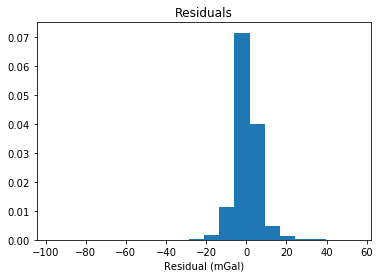

In [ ]:
plt.title('Residuals')
plt.hist(residuals, bins=20, normed=True)
plt.xlabel('Residual (mGal)')
print('Mean: {}   std: {}'.format(residuals.mean(), residuals.std()))

In [ ]:
moho = solver[0].estimate_
moho_result=-0.001*moho.relief.reshape(moho.shape)

<Figure size 1296x432 with 0 Axes>

Text(0.5,1,u'Estimated Moho depth')

(1.3966480472138443e-08, 178.99999501396647)

(-90.0, 89.0)

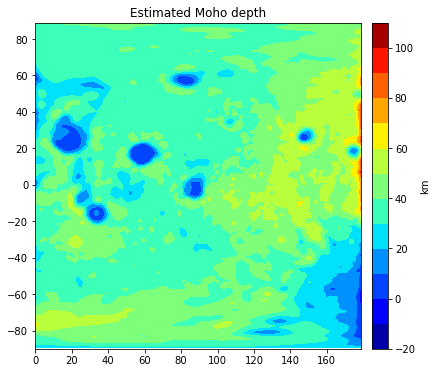

In [ ]:
plt.figure(figsize=(18, 6))
plt.title("Estimated Moho depth")
levels = mpl.contourf(LON_sub, LAT_sub, moho_result, moho_result.shape, 12, cmap='jet')
plt.colorbar(pad=0.01).set_label('km')
plt.xlim(moho.lons.min(), moho.lons.max())
plt.ylim(moho.lats.min(), moho.lats.max())
plt.gca().set_aspect('equal', adjustable='box')

<Figure size 1296x432 with 0 Axes>

Text(0.5,1,u'Estimated Moho depth')

(1.3966480472138443e-08, 178.99999501396647)

(-90.0, 89.0)

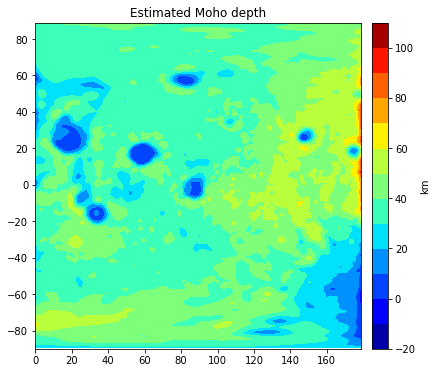

In [ ]:
plt.figure(figsize=(18, 6))
plt.title("Estimated Moho depth")
levels = mpl.contourf(LON_sub, LAT_sub, moho_result, moho_result.shape, 12, cmap='jet')
plt.colorbar(pad=0.01).set_label('km')
plt.xlim(moho.lons.min(), moho.lons.max())
plt.ylim(moho.lats.min(), moho.lats.max())
plt.gca().set_aspect('equal', adjustable='box')

In [ ]:
result=dict()
result['LON']=LON_sub
result['LAT']=LAT_sub
result['observe']=grav_grid_sub
result['predict']=predicted
result['moho_grid']=moho_result
result['residuals']=residuals

with open(pkl_name, "wb") as f:
    pickle.dump(result, f)